# Sistema de Recomendacion de Trayectorias para Mejorar el Ingreso

En este proyecto vamos a construir un sistema de recomendacion usando el dataset **Adult Census Income**.
La idea es, dado el perfil de una persona (edad, educacion, ocupacion, horas trabajadas, etc.), recomendar
que caracteristicas o trayectorias tienen en comun las personas que ganan mas de 50K dolares al año.

## Estructura del notebook

1. Carga del dataset
2. Exploracion inicial
3. Preprocesamiento
4. Definicion del problema de recomendacion
5. Construccion del sistema (filtrado basado en contenido)
6. Pruebas con perfiles simulados

## 1. Importacion de librerias

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Para que los graficos se vean dentro del notebook
%matplotlib inline

# Estilo visual de los graficos
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Carga del dataset

El dataset contiene informacion demografica y laboral de personas.
La variable objetivo es `income`, que indica si la persona gana mas o menos de 50K dolares anuales.

In [30]:
# Cargamos el archivo CSV
df = pd.read_csv('../data/raw/adult-census-income.csv')

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [29]:
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])
print()
print(df.dtypes)

Filas: 32561
Columnas: 16

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
income_bin        int64
dtype: object


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 3. Exploracion inicial

Antes de limpiar los datos, conviene ver como estan distribuidas las variables mas importantes.

income
<=50K    24720
>50K      7841
Name: count, dtype: int64



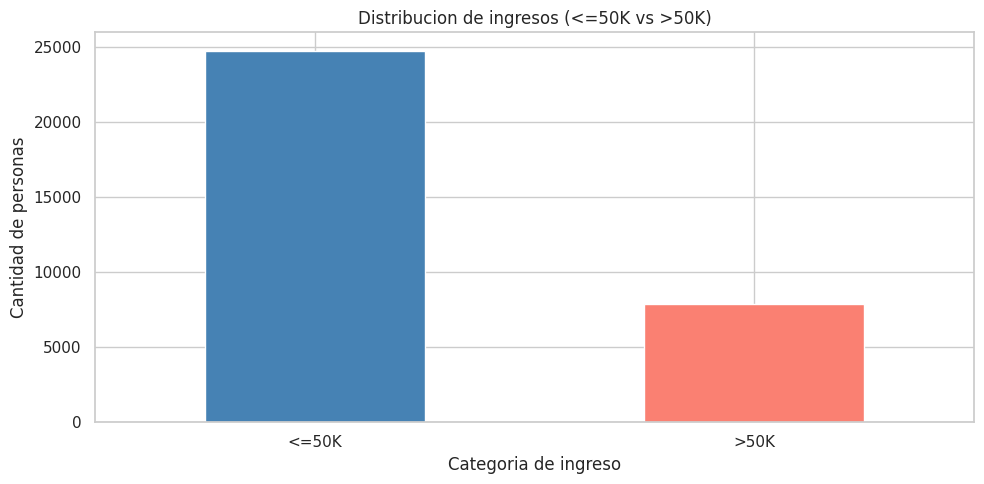

In [31]:
# Distribucion de la variable objetivo (ingreso)
conteo_ingreso = df['income'].value_counts()
print(conteo_ingreso)
print()

conteo_ingreso.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribucion de ingresos (<=50K vs >50K)')
plt.xlabel('Categoria de ingreso')
plt.ylabel('Cantidad de personas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

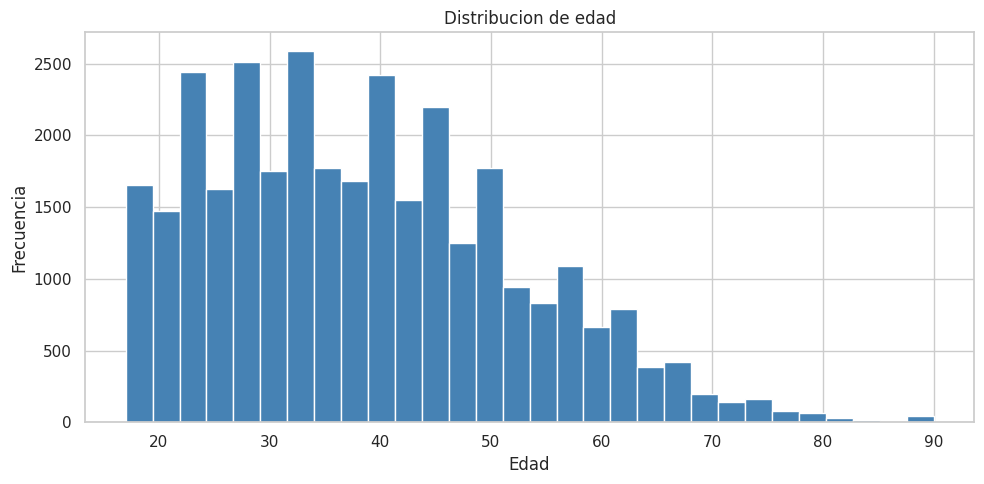

In [9]:
# Distribucion de edad
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribucion de edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

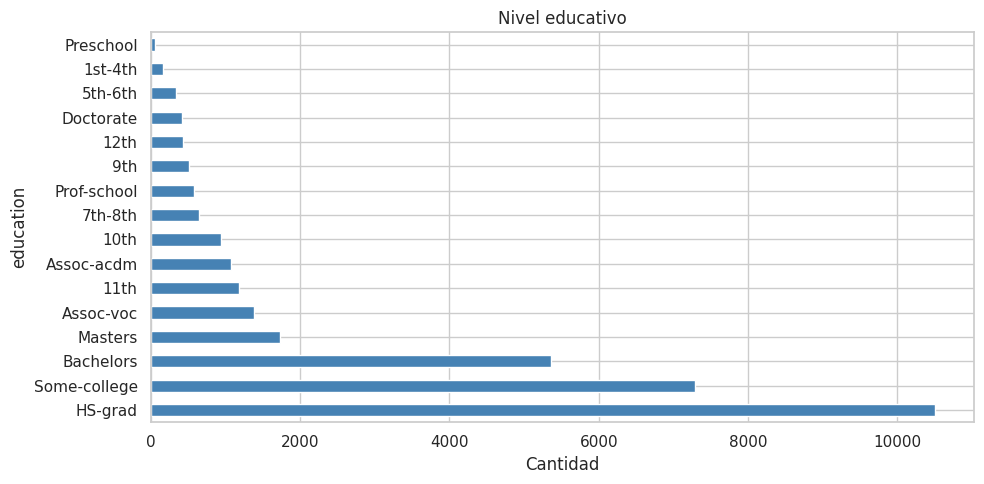

In [32]:
# Distribucion de nivel educativo
conteo_edu = df['education'].value_counts()

conteo_edu.plot(kind='barh', color='steelblue')
plt.title('Nivel educativo')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

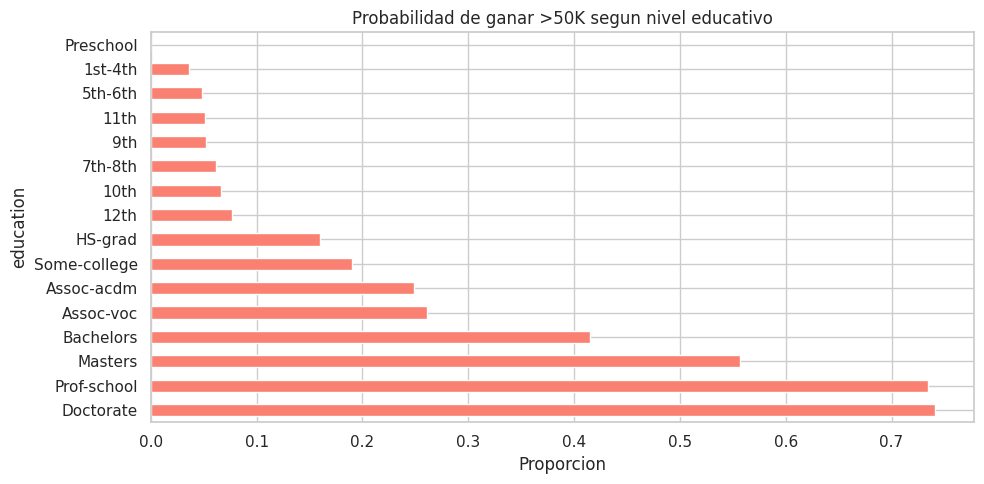

In [11]:
# Porcentaje de personas que ganan >50K segun nivel educativo
# Primero convertimos income a 0/1 para poder calcular promedios
df['income_bin'] = (df['income'].str.strip() == '>50K').astype(int)

ingreso_por_edu = df.groupby('education')['income_bin'].mean().sort_values(ascending=False)

ingreso_por_edu.plot(kind='barh', color='salmon')
plt.title('Probabilidad de ganar >50K segun nivel educativo')
plt.xlabel('Proporcion')
plt.tight_layout()
plt.show()

## 4. Preprocesamiento de datos

Vamos a:
- Limpiar espacios en los valores de texto (el dataset tiene espacios al inicio en algunas columnas)
- Reemplazar valores '?' por NaN y luego tratar los nulos
- Codificar variables categoricas con LabelEncoder
- Normalizar variables numericas con MinMaxScaler

In [12]:
# Hacemos una copia para no modificar el original
df_clean = df.copy()

# El dataset tiene espacios al inicio en las columnas de texto, los limpiamos
columnas_texto = df_clean.select_dtypes(include='object').columns

for col in columnas_texto:
    df_clean[col] = df_clean[col].str.strip()

print('Espacios eliminados en columnas de texto.')

Espacios eliminados en columnas de texto.


In [13]:
# Reemplazamos '?' por NaN
df_clean.replace('?', np.nan, inplace=True)

# Contamos cuantos nulos hay por columna
print('Valores nulos por columna:')
print(df_clean.isnull().sum())

Valores nulos por columna:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
income_bin           0
dtype: int64


In [14]:
# Las columnas con nulos son: workclass, occupation, native.country
# Como son categoricas, las rellenamos con la moda (valor mas frecuente)

for col in ['workclass', 'occupation', 'native.country']:
    if col in df_clean.columns:
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f'{col}: nulos rellenados con "{moda}"')

print()
print('Nulos restantes:', df_clean.isnull().sum().sum())

workclass: nulos rellenados con "Private"
occupation: nulos rellenados con "Prof-specialty"
native.country: nulos rellenados con "United-States"

Nulos restantes: 4262


In [15]:
# Seleccionamos las columnas que vamos a usar en el modelo
# Dejamos fuera 'fnlwgt' (peso estadistico, no relevante para recomendacion)
# y 'education' porque ya tenemos 'education.num' que es su version numerica

columnas_modelo = [
    'age',
    'workclass',
    'education.num',
    'marital.status',
    'occupation',
    'relationship',
    'sex',
    'hours.per.week',
    'native.country',
    'income'
]

# Nos quedamos solo con esas columnas
df_modelo = df_clean[columnas_modelo].copy()

print('Columnas seleccionadas:')
print(df_modelo.columns.tolist())

Columnas seleccionadas:
['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'sex', 'hours.per.week', 'native.country', 'income']


In [16]:
# Codificamos la variable objetivo como 0 y 1
df_modelo['income_bin'] = (df_modelo['income'] == '>50K').astype(int)
df_modelo.drop(columns=['income'], inplace=True)

# Codificamos las variables categoricas con LabelEncoder
# Guardamos los encoders para poder usarlos luego con perfiles nuevos
encoders = {}
columnas_categoricas = ['workclass', 'marital.status', 'occupation', 'relationship', 'sex', 'native.country']

for col in columnas_categoricas:
    le = LabelEncoder()
    df_modelo[col] = le.fit_transform(df_modelo[col])
    encoders[col] = le  # guardamos el encoder para cada columna

print('Variables categoricas codificadas.')
df_modelo.head()

Variables categoricas codificadas.


,age,workclass,education.num,marital.status,occupation,relationship,sex,hours.per.week,native.country,income_bin
0,90,8,9,6,14,1,0,40,38,0
1,82,3,9,6,3,1,0,18,38,0
2,66,8,10,6,14,4,0,40,38,0
3,54,3,4,0,6,4,0,40,38,0
4,41,3,10,5,9,3,0,40,38,0


In [17]:
# Normalizamos las variables numericas entre 0 y 1
# Guardamos el scaler para usarlo con perfiles nuevos

columnas_numericas = ['age', 'education.num', 'hours.per.week']

scaler = MinMaxScaler()
df_modelo[columnas_numericas] = scaler.fit_transform(df_modelo[columnas_numericas])

print('Variables numericas normalizadas.')
df_modelo.head()

Variables numericas normalizadas.


,age,workclass,education.num,marital.status,occupation,relationship,sex,hours.per.week,native.country,income_bin
0,1.000000,8,0.533333,6,14,1,0,0.397959,38,0
1,0.890411,3,0.533333,6,3,1,0,0.173469,38,0
2,0.671233,8,0.600000,6,14,4,0,0.397959,38,0
3,0.506849,3,0.200000,0,6,4,0,0.397959,38,0
4,0.328767,3,0.600000,5,9,3,0,0.397959,38,0


## 5. Definicion del problema de recomendacion

**Que queremos recomendar?**
Dada una persona con ciertas caracteristicas, queremos encontrar personas "similares" que ganan mas de 50K
y analizar que tienen en comun (ocupacion, nivel educativo, estado civil, horas trabajadas).
Eso nos da pistas sobre que cambios en el perfil podrian llevar a un mejor ingreso.

**Quien es el usuario?**
Cualquier persona de la que conocemos su informacion demografica y laboral.

**Que variables definen el perfil?**
- Edad
- Nivel educativo (en numero)
- Sector laboral (workclass)
- Estado civil
- Ocupacion
- Relacion familiar
- Sexo
- Horas trabajadas por semana
- Pais de origen

**Enfoque elegido: Filtrado basado en contenido**
Representamos a cada persona como un vector numerico y calculamos la similitud coseno
entre el perfil del usuario nuevo y todos los perfiles del dataset.
Nos quedamos con los mas similares que ganan >50K y analizamos su perfil.

## 6. Construccion del sistema de recomendacion

La logica es simple:
1. Recibimos el perfil de un usuario nuevo
2. Lo transformamos igual que el resto del dataset (encoding + normalizacion)
3. Calculamos similitud  entre ese perfil y todos los del dataset
4. Filtramos solo los que ganan >50K
5. Devolvemos los N mas similares y describimos su perfil

In [33]:
# Separamos las features (variables de entrada) de la variable objetivo
feature_cols = [col for col in df_modelo.columns if col != 'income_bin']

X = df_modelo[feature_cols].values  
y = df_modelo['income_bin'].values 

In [34]:
def preprocesar_perfil(perfil_dict, encoders, scaler, columnas_categoricas, columnas_numericas, feature_cols):
   
    perfil = perfil_dict.copy()
    
    # Codificamos las variables categoricas
    for col in columnas_categoricas:
        le = encoders[col]
        valor = perfil[col]
        
        # Si el valor no esta en el encoder, usamos el mas frecuente
        if valor not in le.classes_:
            print(f'Aviso: "{valor}" no existe en "{col}". Se usara el valor por defecto.')
            valor = le.classes_[0]
        
        perfil[col] = le.transform([valor])[0]
    
    # Construimos un dataframe con una sola fila en el orden correcto
    df_perfil = pd.DataFrame([perfil])[feature_cols]
    
    # Normalizamos las variables numericas
    df_perfil[columnas_numericas] = scaler.transform(df_perfil[columnas_numericas])
    
    return df_perfil.values

In [35]:
def recomendar_trayectorias(perfil_vector, X, y, df_original, df_clean, top_n=10):
    
    similitudes = cosine_similarity(perfil_vector, X)[0]
    
    # Indices de las personas que ganan >50K
    indices_altos = np.where(y == 1)[0]
    
    # Similitudes solo de esas personas
    similitudes_altos = similitudes[indices_altos]
    
    # Ordenamos de mayor a menor similitud y nos quedamos con los top_n
    top_indices_locales = np.argsort(similitudes_altos)[::-1][:top_n]
    top_indices_globales = indices_altos[top_indices_locales]
    
    # Recuperamos los datos originales de esas personas
    top_perfiles = df_clean.iloc[top_indices_globales][columnas_modelo[:-1]].copy()
    top_perfiles['similitud'] = similitudes[top_indices_globales].round(4)
    top_perfiles['income'] = '>50K'
    
    return top_perfiles

In [36]:
def analizar_recomendaciones(top_perfiles):

    print('--- Resumen de perfiles recomendados (personas similares que ganan >50K) ---')
    print()
    
    print('Ocupaciones mas frecuentes:')
    print(top_perfiles['occupation'].value_counts().head(5))
    print()
    
    print('Estado civil mas frecuente:')
    print(top_perfiles['marital.status'].value_counts().head(3))
    print()
    
    print('Sector laboral (workclass):')
    print(top_perfiles['workclass'].value_counts().head(3))
    print()
    
    print('Horas trabajadas por semana (promedio):')
    print(round(top_perfiles['hours.per.week'].mean(), 1))
    print()
    
    print('Nivel educativo promedio (en numero):')
    print(round(top_perfiles['education.num'].mean(), 1))
    print()
    
    return top_perfiles

## 7. Pruebas con perfiles simulados

Vamos a crear varios perfiles de usuarios hipoteticos y ver que recomendaciones les da el sistema.

### Caso 1: Persona joven con secundario completo, trabaja medio tiempo

In [ ]:
# education.num = 9 equivale a HS-grad (secundario completo)

perfil_usuario_1 = {
    'age': 25,
    'workclass': 'Private',
    'education.num': 9,
    'marital.status': 'Never-married',
    'occupation': 'Other-service',
    'relationship': 'Own-child',
    'sex': 'Male',
    'hours.per.week': 20,
    'native.country': 'United-States'
}

# Preprocesamos el perfil
vector_1 = preprocesar_perfil(
    perfil_usuario_1,
    encoders,
    scaler,
    columnas_categoricas,
    columnas_numericas,
    feature_cols
)

# Buscamos los perfiles mas similares que ganan >50K
recomendaciones_1 = recomendar_trayectorias(vector_1, X, y, df, df_clean, top_n=20)

print('Perfil del usuario 1:')
for k, v in perfil_usuario_1.items():
    print(f'  {k}: {v}')
print()

# Analizamos que tienen en comun los perfiles similares que ganan mas
analizar_recomendaciones(recomendaciones_1)

Perfil del usuario 1:
  age: 25
  workclass: Private
  education.num: 9
  marital.status: Never-married
  occupation: Other-service
  relationship: Own-child
  sex: Male
  hours.per.week: 20
  native.country: United-States

--- Resumen de perfiles recomendados (personas similares que ganan >50K) ---

Ocupaciones mas frecuentes:
occupation
Other-service        9
Prof-specialty       9
Machine-op-inspct    2
Name: count, dtype: int64

Estado civil mas frecuente:
marital.status
Never-married            17
Married-spouse-absent     1
Separated                 1
Name: count, dtype: int64

Sector laboral (workclass):
workclass
Private             18
Self-emp-not-inc     1
Self-emp-inc         1
Name: count, dtype: int64

Horas trabajadas por semana (promedio):
44.2

Nivel educativo promedio (en numero):
11.0



,age,workclass,education.num,marital.status,occupation,relationship,sex,hours.per.week,native.country,similitud,income
24514,22,Private,10,Never-married,Other-service,Own-child,Male,32,United-States,1.0000,>50K
13954,45,Private,9,Married-spouse-absent,Other-service,Unmarried,Female,60,United-States,0.9989,>50K
2263,44,Private,13,Never-married,Prof-specialty,Own-child,Male,40,United-States,0.9987,>50K
15578,35,Private,14,Never-married,Prof-specialty,Own-child,Male,44,United-States,0.9987,>50K
6953,33,Private,15,Never-married,Prof-specialty,Own-child,Male,42,United-States,0.9987,>50K
2271,26,Private,13,Never-married,Prof-specialty,Own-child,Male,64,United-States,0.9987,>50K
5276,44,Private,13,Never-married,Other-service,Not-in-family,Male,40,United-States,0.9986,>50K
10961,19,Private,4,Never-married,Other-service,Not-in-family,Male,60,United-States,0.9986,>50K
176,23,Private,13,Never-married,Prof-specialty,Own-child,Female,40,United-States,0.9984,>50K
1354,28,Private,13,Never-married,Prof-specialty,Own-child,Female,40,United-States,0.9984,>50K


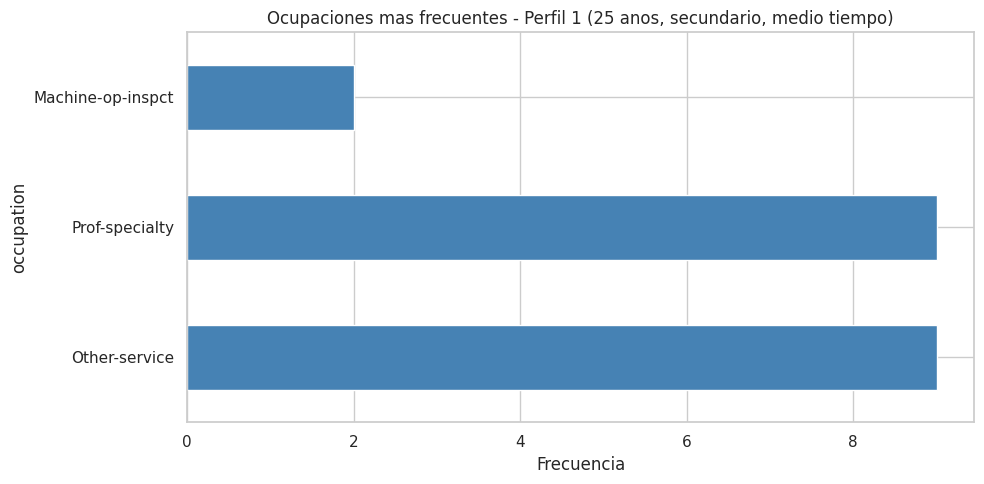

In [ ]:
# Visualizacion: ocupaciones mas frecuentes entre las recomendaciones del usuario 1
top_ocup_1 = recomendaciones_1['occupation'].value_counts().head(8)

top_ocup_1.plot(kind='barh', color='steelblue')
plt.title('Ocupaciones mas frecuentes - Perfil 1 (25 años, secundario, medio tiempo)')
plt.xlabel('Frecuencia')
plt.tight_layout()
plt.show()

### Caso 2: Mujer de 35 años con estudios universitarios, trabaja tiempo completo

In [ ]:
# education.num = 13 equivale a Bachelors

perfil_usuario_2 = {
    'age': 35,
    'workclass': 'Private',
    'education.num': 13,
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Adm-clerical',
    'relationship': 'Wife',
    'sex': 'Female',
    'hours.per.week': 40,
    'native.country': 'United-States'
}

vector_2 = preprocesar_perfil(
    perfil_usuario_2,
    encoders,
    scaler,
    columnas_categoricas,
    columnas_numericas,
    feature_cols
)

recomendaciones_2 = recomendar_trayectorias(vector_2, X, y, df, df_clean, top_n=20)

print('Perfil del usuario 2:')
for k, v in perfil_usuario_2.items():
    print(f'  {k}: {v}')
print()

analizar_recomendaciones(recomendaciones_2)

Perfil del usuario 2:
  age: 35
  workclass: Private
  education.num: 13
  marital.status: Married-civ-spouse
  occupation: Adm-clerical
  relationship: Wife
  sex: Female
  hours.per.week: 40
  native.country: United-States

--- Resumen de perfiles recomendados (personas similares que ganan >50K) ---

Ocupaciones mas frecuentes:
occupation
Adm-clerical    20
Name: count, dtype: int64

Estado civil mas frecuente:
marital.status
Married-civ-spouse    20
Name: count, dtype: int64

Sector laboral (workclass):
workclass
Private    20
Name: count, dtype: int64

Horas trabajadas por semana (promedio):
40.2

Nivel educativo promedio (en numero):
11.9



,age,workclass,education.num,marital.status,occupation,relationship,sex,hours.per.week,native.country,similitud,income
18651,31,Private,13,Married-civ-spouse,Adm-clerical,Wife,Female,40,United-States,1.0,>50K
31409,31,Private,13,Married-civ-spouse,Adm-clerical,Wife,Female,40,United-States,1.0,>50K
28431,34,Private,12,Married-civ-spouse,Adm-clerical,Wife,Female,40,United-States,1.0,>50K
4783,30,Private,13,Married-civ-spouse,Adm-clerical,Wife,Female,40,United-States,1.0,>50K
22159,42,Private,13,Married-civ-spouse,Adm-clerical,Wife,Female,40,United-States,1.0,>50K
25256,38,Private,13,Married-civ-spouse,Adm-clerical,Wife,Female,50,United-States,1.0,>50K
6159,42,Private,12,Married-civ-spouse,Adm-clerical,Wife,Female,40,United-States,1.0,>50K
23120,26,Private,13,Married-civ-spouse,Adm-clerical,Wife,Female,40,United-States,1.0,>50K
17102,37,Private,11,Married-civ-spouse,Adm-clerical,Wife,Female,48,United-States,1.0,>50K
2418,41,Private,11,Married-civ-spouse,Adm-clerical,Wife,Female,44,United-States,1.0,>50K


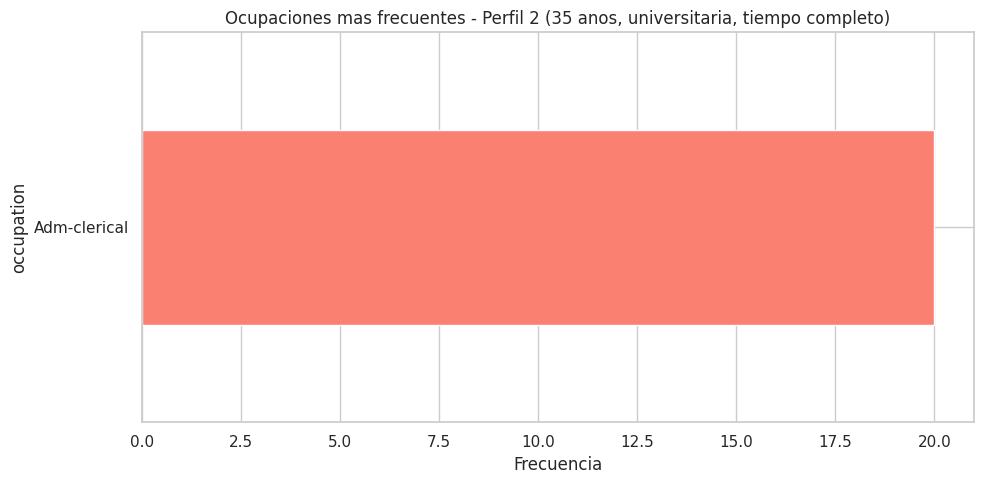

In [ ]:
# Visualizacion: ocupaciones para el perfil 2
top_ocup_2 = recomendaciones_2['occupation'].value_counts().head(8)

top_ocup_2.plot(kind='barh', color='salmon')
plt.title('Ocupaciones mas frecuentes - Perfil 2 (35 años, universitaria, tiempo completo)')
plt.xlabel('Frecuencia')
plt.tight_layout()
plt.show()

### Caso 3: Hombre de 45 años, sin estudios universitarios, sector publico

In [ ]:
# education.num = 10 equivale a Some-college

perfil_usuario_3 = {
    'age': 45,
    'workclass': 'State-gov',
    'education.num': 10,
    'marital.status': 'Divorced',
    'occupation': 'Craft-repair',
    'relationship': 'Unmarried',
    'sex': 'Male',
    'hours.per.week': 40,
    'native.country': 'United-States'
}

vector_3 = preprocesar_perfil(
    perfil_usuario_3,
    encoders,
    scaler,
    columnas_categoricas,
    columnas_numericas,
    feature_cols
)

recomendaciones_3 = recomendar_trayectorias(vector_3, X, y, df, df_clean, top_n=20)

print('Perfil del usuario 3:')
for k, v in perfil_usuario_3.items():
    print(f'  {k}: {v}')
print()

analizar_recomendaciones(recomendaciones_3)

Perfil del usuario 3:
  age: 45
  workclass: State-gov
  education.num: 10
  marital.status: Divorced
  occupation: Craft-repair
  relationship: Unmarried
  sex: Male
  hours.per.week: 40
  native.country: United-States

--- Resumen de perfiles recomendados (personas similares que ganan >50K) ---

Ocupaciones mas frecuentes:
occupation
Exec-managerial    14
Craft-repair        3
Adm-clerical        2
Farming-fishing     1
Name: count, dtype: int64

Estado civil mas frecuente:
marital.status
Divorced              14
Married-civ-spouse     6
Name: count, dtype: int64

Sector laboral (workclass):
workclass
State-gov           10
Self-emp-not-inc     8
Self-emp-inc         2
Name: count, dtype: int64

Horas trabajadas por semana (promedio):
45.2

Nivel educativo promedio (en numero):
10.6



,age,workclass,education.num,marital.status,occupation,relationship,sex,hours.per.week,native.country,similitud,income
2357,48,State-gov,9,Divorced,Craft-repair,Own-child,Male,40,United-States,0.9997,>50K
1688,55,Self-emp-not-inc,9,Divorced,Craft-repair,Unmarried,Male,55,United-States,0.9997,>50K
31151,45,State-gov,9,Divorced,Exec-managerial,Unmarried,Female,38,United-States,0.9993,>50K
1720,51,Self-emp-not-inc,14,Divorced,Exec-managerial,Unmarried,Male,50,United-States,0.9993,>50K
27687,31,State-gov,14,Divorced,Exec-managerial,Unmarried,Female,50,United-States,0.9993,>50K
13770,31,Self-emp-not-inc,13,Divorced,Exec-managerial,Unmarried,Male,60,United-States,0.9993,>50K
2188,49,Self-emp-not-inc,9,Divorced,Exec-managerial,Unmarried,Female,30,United-States,0.9990,>50K
4247,43,Self-emp-not-inc,14,Divorced,Exec-managerial,Unmarried,Female,45,United-States,0.9990,>50K
9458,57,Self-emp-not-inc,6,Divorced,Exec-managerial,Own-child,Male,60,United-States,0.9990,>50K
169,46,State-gov,12,Divorced,Adm-clerical,Unmarried,Male,38,United-States,0.9987,>50K


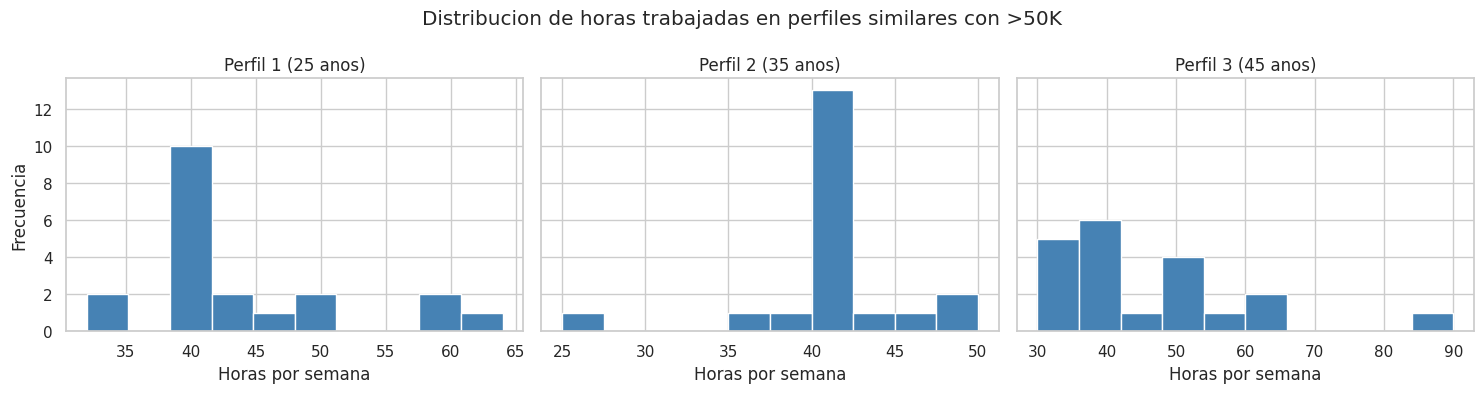

In [ ]:
# Visualizacion: horas trabajadas entre los perfiles similares de los 3 casos

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, (rec, titulo) in enumerate([
    (recomendaciones_1, 'Perfil 1 (25 años)'),
    (recomendaciones_2, 'Perfil 2 (35 años)'),
    (recomendaciones_3, 'Perfil 3 (45 años)')
]):
    axes[i].hist(rec['hours.per.week'], bins=10, color='steelblue', edgecolor='white')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('Horas por semana')
    if i == 0:
        axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribucion de horas trabajadas en perfiles similares con >50K')
plt.tight_layout()
plt.show()

## 8. Comparacion de los tres perfiles

Hacemos un cuadro comparativo de lo que los perfiles similares tienen en comun.

In [37]:
# Construimos una tabla resumen comparando los 3 perfiles

def resumen_perfil(rec, nombre_perfil):
    return {
        'Perfil': nombre_perfil,
        'Ocupacion mas comun': rec['occupation'].value_counts().index[0],
        'Estado civil mas comun': rec['marital.status'].value_counts().index[0],
        'Workclass mas comun': rec['workclass'].value_counts().index[0],
        'Horas promedio': round(rec['hours.per.week'].mean(), 1),
        'Edu.num promedio': round(rec['education.num'].mean(), 1)
    }

comparacion = pd.DataFrame([
    resumen_perfil(recomendaciones_1, 'Perfil 1 - 25 años, secundario'),
    resumen_perfil(recomendaciones_2, 'Perfil 2 - 35 años, universitaria'),
    resumen_perfil(recomendaciones_3, 'Perfil 3 - 45 años, algo de uni')
])

comparacion.set_index('Perfil', inplace=True)
comparacion

,Ocupacion mas comun,Estado civil mas comun,Workclass mas comun,Horas promedio,Edu.num promedio
Perfil,,,,,
"Perfil 1 - 25 años, secundario",Other-service,Never-married,Private,44.2,11.0
"Perfil 2 - 35 años, universitaria",Adm-clerical,Married-civ-spouse,Private,40.2,11.9
"Perfil 3 - 45 años, algo de uni",Exec-managerial,Divorced,State-gov,45.2,10.6


## 9. Conclusiones

El sistema de recomendacion construido permite, dado el perfil de una persona, encontrar personas similares
que ganan mas de 50K y analizar que tienen en comun.

Algunas observaciones generales que surgen de los datos:

- Las personas con mayor nivel educativo (educacion universitaria completa) tienen mayor probabilidad de pertenecer al grupo de altos ingresos.
- Las ocupaciones asociadas a ingresos altos suelen ser de tipo gerencial, tecnico o profesional (Exec-managerial, Prof-specialty, Tech-support).
- Las horas trabajadas por semana tambien juegan un rol importante: los perfiles similares suelen trabajar entre 40 y 50 horas.
- El estado civil 'Married-civ-spouse' aparece con frecuencia en los perfiles de altos ingresos.

**Limitaciones del sistema:**
- La similitud coseno no considera relaciones causales: encontrar personas similares que ganan mas no implica que copiar su perfil garantice mejores ingresos.
- El dataset es del censo de los 90s de Estados Unidos, por lo que los patrones pueden no ser representativos hoy.
- Para un sistema mas robusto se podria explorar filtrado colaborativo o modelos supervisados de clasificacion.